<a href="https://colab.research.google.com/github/DHRUVCHARNE/AI-Learn-Notebooks/blob/main/makemore_mlp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
#read words
words = open('/content/names.txt','r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [5]:
len(words)

32033

In [6]:
# Build the Vocab and the mapping from and to integers
chars = sorted(list(set(''.join(words))))
stoi={s:i for i,s in enumerate(chars)}
stoi['.']=0
itos = {i:s for s,i in stoi.items()}
vocab_size=len(itos)
print(itos)
print(vocab_size)

{0: '.', 1: 'b', 2: 'c', 3: 'd', 4: 'e', 5: 'f', 6: 'g', 7: 'h', 8: 'i', 9: 'j', 10: 'k', 11: 'l', 12: 'm', 13: 'n', 14: 'o', 15: 'p', 16: 'q', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'w', 23: 'x', 24: 'y', 25: 'z'}
26


In [7]:
# Build the dataset
block_size = 3
def build_dataset(words):
  X,Y = [],[]
  for w in words:
    context = [0]*block_size
    for ch in w + '.':
      ix=stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape,Y.shape)
  return X,Y

In [8]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2=int(0.9 * len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [94]:
# MLP Revisited
n_emb = 10 # Dimensionality of the character embedding vectors
n_hidden = 200 # The Number of neurons in the hidden layer
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_emb),generator=g)
W1 = torch.randn((n_emb*block_size,n_hidden),generator=g)*(5/3)/((n_emb*block_size)**0.5)
#b1= torch.randn(n_hidden,generator=g)*(5/3)/(n_hidden**0.5)
W2=torch.randn((n_hidden,vocab_size),generator=g)*(5/3)/(n_hidden**0.5)
b2 = torch.randn(vocab_size,generator=g)*(5/3)/(vocab_size**0.5)
bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.ones((1,n_hidden))
bnstd_running = torch.zeros((1,n_hidden))
parameters = [C,W1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad=True

11886


tensor(-0.0004) tensor(0.0533)
tensor(-0.0001) tensor(0.0877)


(array([2.58499361e-04, 0.00000000e+00, 2.58499361e-04, 7.75498083e-04,
        1.55099617e-03, 1.55099617e-03, 3.36049169e-03, 3.36049169e-03,
        8.78897827e-03, 1.34419668e-02, 1.99044508e-02, 3.12784227e-02,
        5.42848658e-02, 8.50462898e-02, 1.41657650e-01, 2.22826449e-01,
        3.51042132e-01, 5.29923690e-01, 7.57920126e-01, 1.11103025e+00,
        1.55358116e+00, 2.08272935e+00, 2.77059615e+00, 3.45044947e+00,
        4.09437138e+00, 4.60620011e+00, 4.86185598e+00, 4.87995094e+00,
        4.48444691e+00, 3.89274188e+00, 3.12965176e+00, 2.51080429e+00,
        1.88678684e+00, 1.31033326e+00, 9.90569551e-01, 6.43663409e-01,
        4.20319961e-01, 2.79696309e-01, 1.93874521e-01, 1.18651207e-01,
        8.03933013e-02, 4.83393805e-02, 2.89519284e-02, 1.99044508e-02,
        1.03399744e-02, 4.91148786e-03, 4.13598978e-03, 2.32649425e-03,
        7.75498083e-04, 2.58499361e-04]),
 array([-0.51852244, -0.49918003, -0.47983763, -0.46049522, -0.44115281,
        -0.4218104 , 

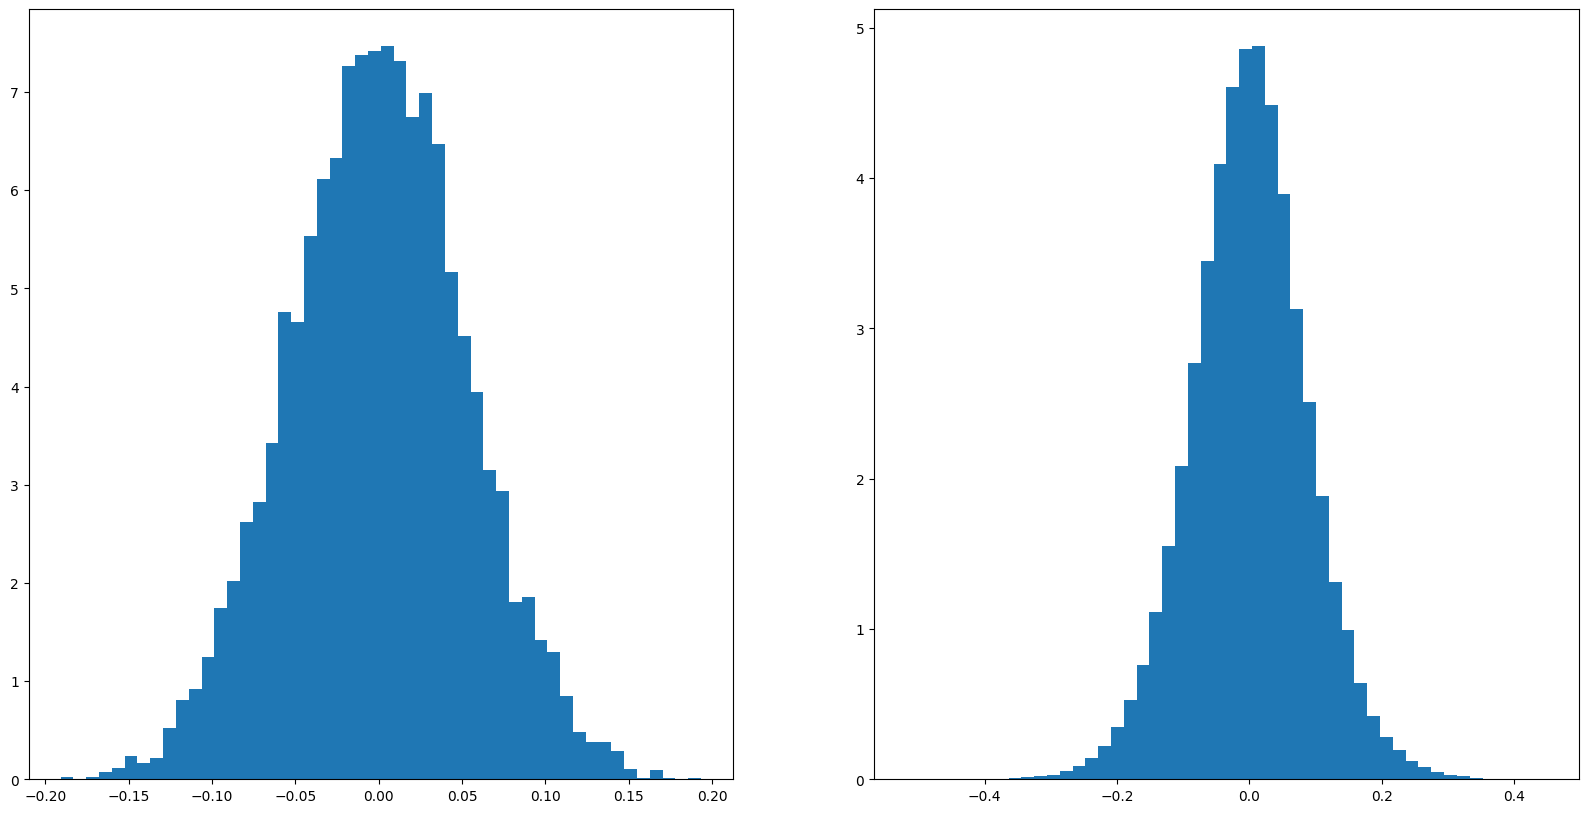

In [95]:
x = torch.randn(1000,10)* (5/3)/(1000**0.5)
w = torch.randn(10,200) * (5/3)/(10**0.5)
y = x @w
print(x.mean(),x.std())
print(y.mean(),y.std())
plt.figure(figsize=(20,10))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True)

In [96]:
# Same Optimization as the last time
max_steps = 200000
batch_size = 32
loss_i = []
for i in range(max_steps):
  #minibatch construct
  ix= torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
  Xb,Yb = Xtr[ix],Ytr[ix]
  #forward pass
  emb = C[Xb] # Embed characters into a vector
  embcat = emb.view(emb.shape[0],-1)
  hpreact=embcat @ W1 #+ b1
  # Batch Normalization
  bnmeani = hpreact.mean(0,keepdim=True)
  bnstdi = hpreact.std(0,keepdim=True)
  hpreact = bngain*((hpreact - bnmeani)/bnstdi) + bnbias
  h =torch.tanh(hpreact)
  logits = h@W2+b2
  loss = F.cross_entropy(logits,Yb)
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  #update
  lr = 0.1 * (0.1 ** (i / max_steps)) # step learning rate decay
  for p in parameters:
    if p.grad is not None:
       p.data += -lr * p.grad
  # track stats
  if i%10000 == 0:
    print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
  loss_i.append(loss.log10().item())

      0/ 200000:3.8974
  10000/ 200000:2.4710
  20000/ 200000:2.1444
  30000/ 200000:1.9448
  40000/ 200000:2.2055
  50000/ 200000:2.0980
  60000/ 200000:2.2255
  70000/ 200000:2.3062
  80000/ 200000:1.9968
  90000/ 200000:2.1507
 100000/ 200000:2.3892
 110000/ 200000:1.8099
 120000/ 200000:2.1914
 130000/ 200000:2.1977
 140000/ 200000:1.9095
 150000/ 200000:1.9008
 160000/ 200000:1.8765
 170000/ 200000:1.8149
 180000/ 200000:2.1957
 190000/ 200000:1.9750


(array([326., 183., 130., 107.,  88.,  74.,  81.,  93.,  60.,  59.,  67.,
         84.,  61.,  71.,  76.,  69.,  64.,  67.,  52.,  57.,  40.,  58.,
         49.,  51.,  58.,  49.,  35.,  32.,  58.,  46.,  53.,  28.,  44.,
         52.,  52.,  48.,  43.,  41.,  34.,  41.,  35.,  30.,  76.,  32.,
         45.,  23.,  57.,  38.,  50.,  53.,  29.,  53.,  51.,  36.,  53.,
         47.,  35.,  47.,  41.,  39.,  43.,  47.,  58.,  35.,  44.,  42.,
         61.,  39.,  52.,  52.,  52.,  65.,  37.,  48.,  64.,  48.,  34.,
         61.,  47.,  36.,  48.,  67.,  66.,  47.,  53.,  59.,  54.,  67.,
         47.,  79.,  74.,  75.,  78.,  69., 103., 100., 112., 112., 177.,
        297.]),
 array([-9.99983788e-01, -9.79984452e-01, -9.59985116e-01, -9.39985780e-01,
        -9.19986444e-01, -8.99987108e-01, -8.79987772e-01, -8.59988436e-01,
        -8.39989100e-01, -8.19989763e-01, -7.99990427e-01, -7.79991091e-01,
        -7.59991755e-01, -7.39992419e-01, -7.19993083e-01, -6.99993747e-01,
        -6.799

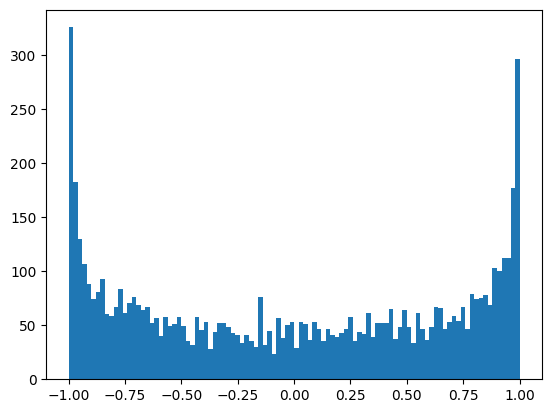

In [97]:
plt.hist(h.view(-1).tolist(),100)

(array([  1.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,   2.,
          1.,   1.,   1.,   4.,   5.,   7.,   5.,   5.,   9.,  11.,   8.,
          6.,  10.,  22.,  26.,  24.,  19.,  33.,  42.,  38.,  52.,  47.,
         50.,  71.,  72.,  72.,  74.,  75.,  93., 109., 131., 112., 173.,
        197., 196., 191., 205., 208., 222., 206., 246., 244., 250., 240.,
        223., 240., 214., 165., 191., 154., 136., 146., 119., 107., 116.,
         89.,  88.,  75.,  51.,  72.,  54.,  41.,  57.,  39.,  24.,  28.,
         23.,  15.,  16.,  21.,  13.,  15.,   7.,   7.,   9.,   6.,   1.,
          2.,   3.,   1.,   3.,   1.,   3.,   2.,   1.,   1.,   1.,   1.,
          1.]),
 array([-5.861166  , -5.74958732, -5.63800863, -5.52642995, -5.41485126,
        -5.30327258, -5.1916939 , -5.08011521, -4.96853653, -4.85695785,
        -4.74537916, -4.63380048, -4.52222179, -4.41064311, -4.29906443,
        -4.18748574, -4.07590706, -3.96432837, -3.85274969, -3.74117101,
        -3.62959232, -3.51

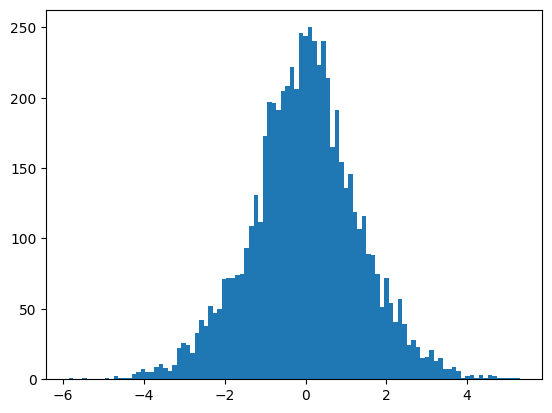

In [98]:
plt.hist(hpreact.view(-1).tolist(),100)

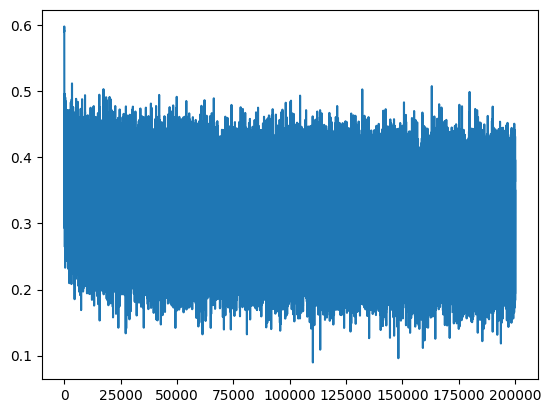

In [99]:
plt.plot(loss_i)

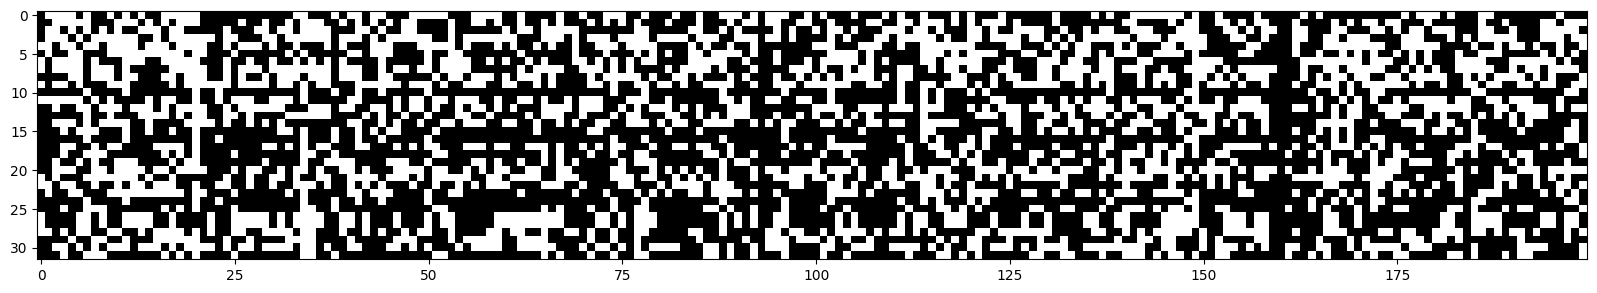

In [100]:
plt.figure(figsize=(20,10))
plt.imshow(hpreact.abs() > 0.99  ,cmap='gray',interpolation='nearest')

In [101]:
# # calibrate the batch norm at the end of training
# with torch.no_grad():
#   # pass the training set through
#   emb = C[Xtr]
#   embcat = emb.view(emb.shape[0],-1)
#   hpreact = embcat @ W1 + b1
#   # measure the mean/std over the entire training set
#   bnmean = hpreact.mean(0,keepdim=True)
#   bnstd = hpreact.std(0,keepdim=True)


In [102]:
@torch.no_grad()
def split_loss(split):
  x,y = {
      'train':(Xtr,Ytr),
      'val':(Xdev,Ydev),
      'test':(Xte,Yte)
  }[split]
  emb = C[x] #(N,block_size,n_emb)
  embcat = emb.view(emb.shape[0],-1) # concat into (N,block_size*n_emb)
  hpreact=embcat @ W1
  # hpreact = bngain*((hpreact - hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True)) + bnbias
  hpreact = bngain*(hpreact - bnmean_running)/bnstd_running+ bnbias
  h=torch.tanh(hpreact) # (N,n_hidden)
  logits = h @ W2 + b2 # (N,vocab_size)
  loss = F.cross_entropy(logits,y)
  print(split,loss.item())
split_loss('train')
split_loss('val')



train 2.022528648376465
val 2.0599262714385986


In [103]:
# Sample from the model
g = torch.Generator().manual_seed(2147483647 + 7)
for _ in range(50):
  out = []
  context = [0] * block_size
  while True:
    emb = C[torch.tensor([context])] # (1,block_size,n_emb)
    h = torch.tanh(emb.view(1,-1) @ W1)
    logits = h @ W2 + b2
    probs = F.softmax(logits,dim=1)
    # Sample from the distribution
    ix = torch.multinomial(probs,num_samples=1,generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

j.
.
c.
jpsmnt.
storikm.
szphurs.
kshemik.
grdebr.
glwfmsterfesmqse.
thurv.
m.
.
k.
phusf.
jerdovrik.
jucklmbrode.
bd.
gdun.
zviethr.
jermikm.
qusl.
g.
christ.
nnixx.
brigl.
ch.
juprel.
jj.
pmrsyn.
.
grexnnxing.
tr.
jwkitzvik.
jhqu.
quikiogsemmyrvosh.
gryxfinithvirv.
kds.
.
bdethmingsncyl.
smrnk.
df.
j.
qg.
pv.
dlr.
grlziqu.
gr.
jrrchriggvizhnnu.
grexz.
trigl.


In [24]:
#Summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
class Linear:
  def __init__(self,fan_in,fan_out,bias=True):
    self.weight = torch.randn((fan_in,fan_out),device=device,generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out,device=device) if bias else None
  def __call__(self,x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])
class BatchNorm1d:
  def __init__(self,dim,eps = 1e-5,momentum=0.1):
    self.eps=eps
    self.training = True
    self.momentum = momentum
    # parameters trained with backprop
    self.gamma = torch.ones(dim,device=device)
    self.beta = torch.zeros(dim,device=device)
    # buffers (trained with a running momentum update)
    self.running_mean = torch.zeros(dim,device=device)
    self.running_var = torch.ones(dim,device=device)
  def __call__(self,x):
    # Calculate the forward pass
    if self.training:
      xmean =x.mean(0,keepdim=True) # batch mean
      xvar = x.var(0,keepdim=True) # batch variance
    else:
      xmean=self.running_mean
      xvar=self.running_var
    #Normalize to unit variance
    xhat=(x-xmean)/torch.sqrt(xvar+self.eps)
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1-self.momentum) *  self.running_mean + self.momentum * xmean
        self.running_var = (1-self.momentum) *  self.running_var + self.momentum * xvar
    return self.out
  def parameters(self):
    return [self.gamma,self.beta]
class Tanh:
  def __call__(self,x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []


cuda


In [25]:
n_embd = 10 # Dimensionality of the character embedding vectors
n_hidden = 100 # Number of neurons in the hidden layer of the MLP
g=torch.Generator(device=device).manual_seed(2147483647)
C=torch.randn((vocab_size,n_embd),generator=g,device=device)
layers = [
    Linear(n_embd * block_size,n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),BatchNorm1d(vocab_size),
]
with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma*=0.1
  # all other layers apply gain
  for layer in layers[:-1]:
    if isinstance(layer,Linear):
       layer.weight*=5/3
parameters = [C]+[p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # No. of parameters in total
for p in parameters:
  p.requires_grad=True


57538


In [34]:
# Same optimization as previous
max_steps = 5000
batch_size=32
lossi=[]
ud=[]
warmup_steps = int(0.05 * max_steps)
Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
import math
def get_lr(i):
    if i < warmup_steps:
        return 0.01 * i / warmup_steps
    else:
        decay_ratio = (i - warmup_steps) / (max_steps - warmup_steps)
        return 1e-4 + 0.5 * (0.01 - 1e-4) * (1 + math.cos(math.pi * decay_ratio))
for i in range(max_steps):
  ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g,device=device)
  Xb,Yb = Xtr[ix].to(device),Ytr[ix].to(device)
  # Forward Pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0],-1) # concatenate vectors
  for layer in layers:
    x=layer(x)
  loss = F.cross_entropy(x,Yb) # loss function
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_grad
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  lr=get_lr(i)
  for p in parameters:
    p.data += -lr * p.grad
  # track stats
  if i%1000 == 0:
    print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([(lr * p.grad.std()/p.data.std()).log10().item() for p in parameters])
  # if i>2000:
  #    break # After_DEBUG would take out obviously to run full optimization


      0/   5000:2.0840
   1000/   5000:1.9386
   2000/   5000:2.7542
   3000/   5000:1.8998
   4000/   5000:2.5564


layer 1 (      Tanh): mean +0.09, std:0.75, saturated: 20.47%
layer 4 (      Tanh): mean -0.00, std:0.63, saturated: 3.22%
layer 7 (      Tanh): mean +0.01, std:0.63, saturated: 3.41%
layer 10 (      Tanh): mean -0.00, std:0.64, saturated: 2.91%
layer 13 (      Tanh): mean -0.00, std:0.64, saturated: 2.78%
layer 16 (      Tanh): mean +0.00, std:0.65, saturated: 1.97%


Text(0.5, 1.0, 'activation distribution')

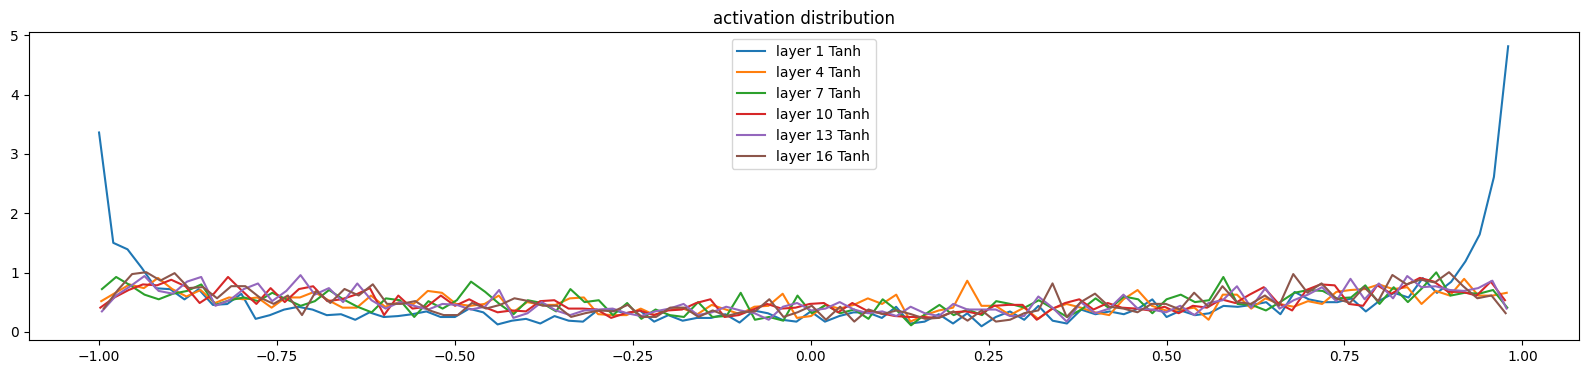

In [35]:
# Visualise histogram
plt.figure(figsize=(20,4))
legends=[]
for i,layer in enumerate(layers[:-1]):
  if isinstance(layer,Tanh):
    t=layer.out.detach().cpu()
    print('layer %d (%10s): mean %+.2f, std:%.2f, saturated: %.2f%%' % (i,layer.__class__.__name__,t.mean(),t.std(),(t.abs()>0.97).float().mean()*100))
    hy,hx = torch.histogram(t,density=True)
    plt.plot(hx[:-1].detach(),hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')
plt.legend(legends)
plt.title('activation distribution')

layer 1 (      Tanh): mean +0.00, std:0.01, saturated: 0.00%
layer 4 (      Tanh): mean -0.00, std:0.01, saturated: 0.00%
layer 7 (      Tanh): mean +0.00, std:0.00, saturated: 0.00%
layer 10 (      Tanh): mean +0.00, std:0.00, saturated: 0.00%
layer 13 (      Tanh): mean -0.00, std:0.00, saturated: 0.00%
layer 16 (      Tanh): mean +0.00, std:0.00, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

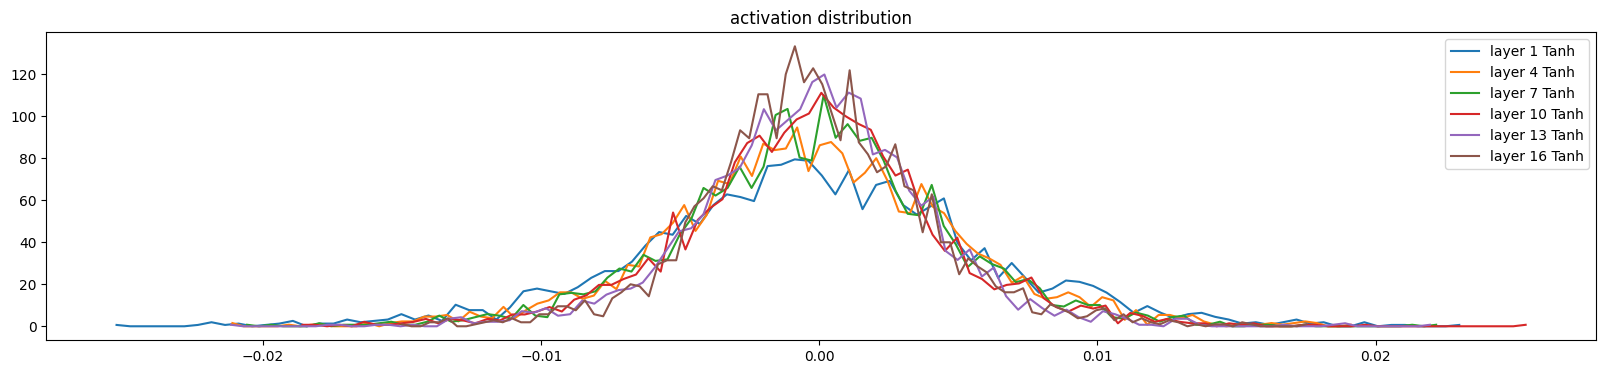

In [36]:
# Visualise histogram
plt.figure(figsize=(20,4))
legends=[]
for i,layer in enumerate(layers[:-1]):
  if isinstance(layer,Tanh):
    t=layer.out.grad.detach().cpu()
    print('layer %d (%10s): mean %+.2f, std:%.2f, saturated: %.2f%%' % (i,layer.__class__.__name__,t.mean(),t.std(),(t.abs()>0.97).float().mean()*100))
    hy,hx = torch.histogram(t,density=True)
    plt.plot(hx[:-1].detach(),hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')
plt.legend(legends)
plt.title('activation distribution')

weight   (26, 10) | mean +0.000356 | std:2.098640e-02 | grad: data ratio 2.031931e-02
weight  (30, 100) | mean -0.000221 | std:1.884326e-02 | grad: data ratio 6.235819e-02
weight (100, 100) | mean +0.000153 | std:1.386794e-02 | grad: data ratio 8.284757e-02
weight (100, 100) | mean -0.000089 | std:1.132767e-02 | grad: data ratio 6.745398e-02
weight (100, 100) | mean +0.000081 | std:1.015475e-02 | grad: data ratio 6.062594e-02
weight (100, 100) | mean -0.000005 | std:9.906879e-03 | grad: data ratio 5.956877e-02
weight (100, 100) | mean +0.000032 | std:9.197660e-03 | grad: data ratio 5.514973e-02
weight  (100, 26) | mean +0.000153 | std:1.774621e-02 | grad: data ratio 1.045821e-01


Text(0.5, 1.0, 'weights gradient distribution')

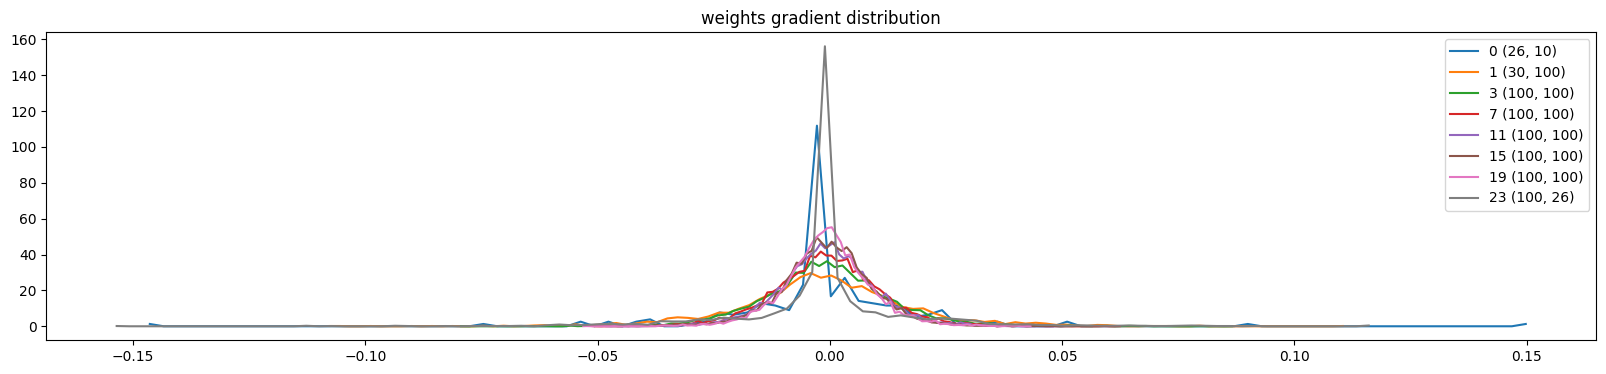

In [37]:
# Visualise histogram
plt.figure(figsize=(20,4))
legends=[]
for i,p in enumerate(parameters):
  t=p.grad.detach().cpu()
  if p.ndim==2:
    print('weight %10s | mean %+f | std:%e | grad: data ratio %e' % (tuple(p.shape),t.mean(),t.std(),t.std()/p.std()))
    hy,hx = torch.histogram(t,density=True)
    plt.plot(hx[:-1].detach(),hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution')

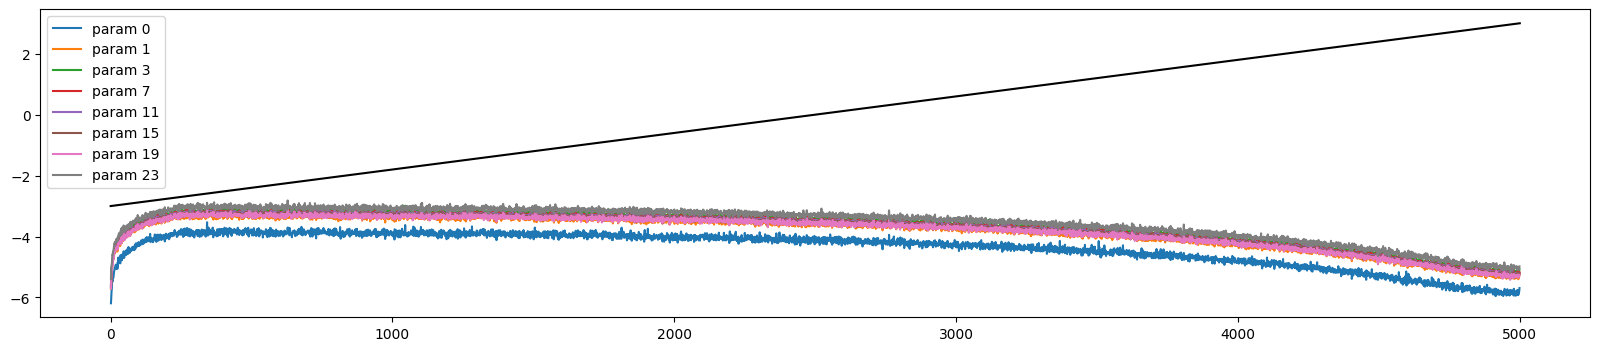

In [38]:
# Visualise histogram
plt.figure(figsize=(20,4))
legends=[]
for i,p in enumerate(parameters):
  if p.ndim==2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0,len(ud)],[-3,3],'k') # these ratios should be ~1e-3 , indicate on plot
plt.legend(legends)